In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import os
import sys
import time
from scipy.stats import pearsonr
from scipy.stats import norm 
import torch

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:

## specify the path to the results of the bootstrap procedure
att_estimation_mimic = pd.read_csv('../results/bootstrap/final_results/mimic_iii_att_estimates_100_tau_0.csv')


In [6]:
methods = ['b_twin','tnet','cfr','dnet','bnet','synctwin']
methods_names = ['B-twin','TARNet','CFRNet','DragonNet','BCAUSS','Synctwin']


tau_est_mimic = list(att_estimation_mimic.iloc[0])
att_estimation_mimic = att_estimation_mimic.iloc[1:]


In [7]:
import matplotlib.pyplot as plt

def plot_intervals(methods, tau_hat, ci_low, ci_high, effect=0):
    """
    methods : liste des noms des méthodes
    tau_hat : liste des estimations
    ci_low  : liste des bornes inférieures
    ci_high : liste des bornes supérieures
    """

    y_pos = range(len(methods))

    plt.figure(figsize=(6, 3))

    # intervalles
    for i in y_pos:
        plt.plot([ci_low[i], ci_high[i]], [i, i])
        plt.plot(tau_hat[i], i, marker='o')

    plt.yticks(y_pos, methods)
    if effect is not None:
        plt.axvline(effect, linestyle='--')  # effet nul
    plt.xlabel("Treatment Effect")
    plt.title("Bootsrap confidence intervals")
    plt.tight_layout()
    plt.show()


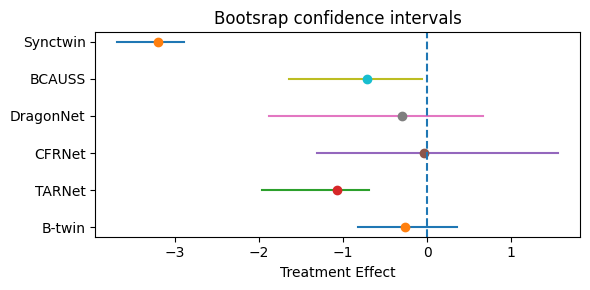

In [8]:
ci_low =[]
ci_high =[]
for i,method in enumerate(methods):
    tau_hat = tau_est_mimic[i]
    tau_boot = att_estimation_mimic[method]

    p = np.mean(tau_boot < tau_hat)
    z0 = norm.ppf(p)

    alpha_low = norm.cdf(2*z0 - 1.96)
    alpha_high = norm.cdf(2*z0 + 1.96)

    CI_low = np.quantile(tau_boot, alpha_low)
    CI_high = np.quantile(tau_boot, alpha_high)
    ci_low.append(CI_low)
    ci_high.append(CI_high)
plot_intervals(methods_names, tau_est_mimic, ci_low, ci_high,effect=0)
